In [10]:
import os
import pandas as pd
import librosa
from tqdm import tqdm

# Define the path to your dataset folder
DATA_PATH = "data/" 

# RAVDESS Emotion mapping based on the 3rd digit of the filename
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

def load_ravdess_data(path):
    file_path = []
    emotion_labels = []
    
    # Traverse through all actor folders
    for actor_folder in os.listdir(path):
        actor_path = os.path.join(path, actor_folder)
        
        if os.path.isdir(actor_path):
            for file in os.listdir(actor_path):
                # Ensure we only pick .wav files
                if file.endswith(".wav"):
                    # Extract the emotion code (the 3rd part of the filename)
                    parts = file.split('-')
                    emotion_code = parts[2]
                    
                    file_path.append(os.path.join(actor_path, file))
                    emotion_labels.append(emotion_map[emotion_code])
    
    # Create a DataFrame to organize the data
    df = pd.DataFrame({
        'path': file_path,
        'emotion': emotion_labels
    })
    return df

# Load the data
data_df = load_ravdess_data(DATA_PATH)
print(f"Total files loaded: {len(data_df)}")
print(data_df.head())

Total files loaded: 1440
                                     path  emotion
0  data/Actor_01\03-01-01-01-01-01-01.wav  neutral
1  data/Actor_01\03-01-01-01-01-02-01.wav  neutral
2  data/Actor_01\03-01-01-01-02-01-01.wav  neutral
3  data/Actor_01\03-01-01-01-02-02-01.wav  neutral
4  data/Actor_01\03-01-02-01-01-01-01.wav     calm


In [15]:
print(data_df['emotion'].value_counts())

emotion
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


In [19]:
import librosa
import numpy as np

def extract_features(file_path):
    # REMOVED: res_type='kaiser_fast' (This was causing the resampy error)
    # Keeping duration and offset helps standardize your audio samples
    try:
        data, sample_rate = librosa.load(file_path, duration=2.5, offset=0.5)
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=40)
        
        # Average across the time axis
        mfccs_scaled = np.mean(mfccs.T, axis=0)
        return mfccs_scaled
        
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

In [21]:
import numpy as np
from tqdm import tqdm

# We will store the results in these lists
features = []
labels = []

print("Extracting features from all files... This will take a few minutes.")

# Loop through our dataframe
for index, row in tqdm(data_df.iterrows(), total=data_df.shape[0]):
    # Use the robust function we updated earlier
    res = extract_features(row['path']) 
    
    if res is not None:
        features.append(res)
        labels.append(row['emotion'])

# Now we create X and y
X = np.array(features)
y = np.array(labels)

print(f"\nSuccess! Features extracted.")
print(f"X shape: {X.shape}") # Should show (1440, 40)
print(f"y shape: {y.shape}") # Should show (1440,)

Extracting features from all files... This will take a few minutes.


100%|██████████████████████████████████████████████████████████████████████████████| 1440/1440 [00:52<00:00, 27.38it/s]


Success! Features extracted.
X shape: (1440, 40)
y shape: (1440,)


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Convert emotion strings into numbers (e.g., 'angry' -> 5)
lb = LabelEncoder()
y_encoded = lb.fit_transform(y)

# 2. Split data: 80% for training the model, 20% for testing it later
# X is your feature matrix from the extraction step
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 3. Scale the data (This is why X_train_scaled was missing!)
# Neural networks work much better when all numbers are in a similar small range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled. You can now train the model!")

Data successfully split and scaled. You can now train the model!


In [23]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the Model
# hidden_layer_sizes=(256,) means one layer with 256 neurons
model = MLPClassifier(alpha=0.01, batch_size=256, epsilon=1e-08, 
                      hidden_layer_sizes=(300,), learning_rate='adaptive', 
                      max_iter=500)

# 2. Train the model
print("Training the model... please wait.")
model.fit(X_train_scaled, y_train)

# 3. Predict on the test set
y_pred = model.predict(X_test_scaled)

# 4. Calculate accuracy
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

Training the model... please wait.
Model Accuracy: 68.40%


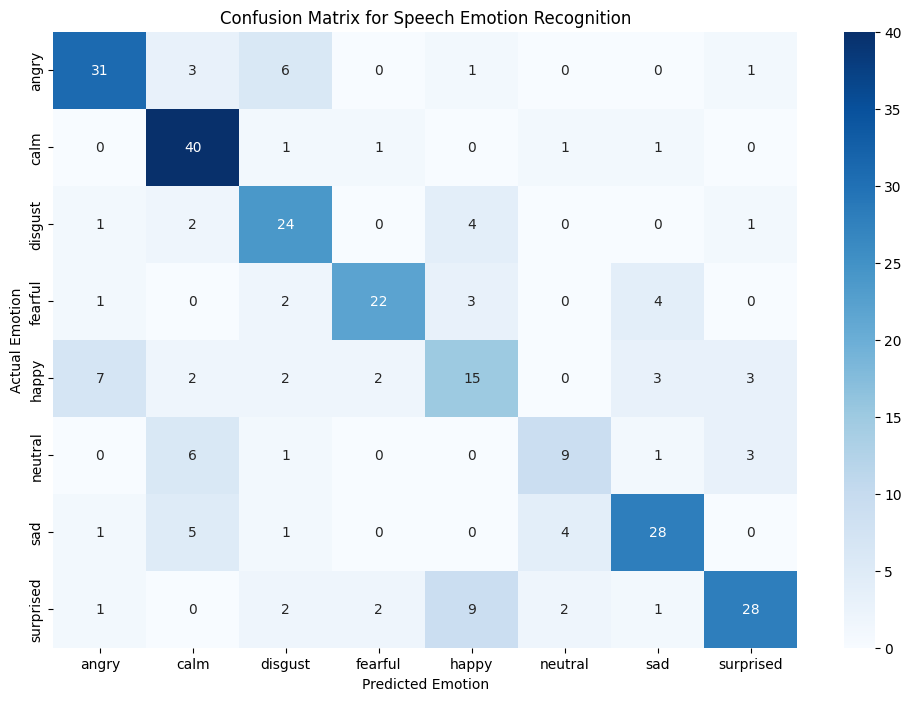

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create the matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))

# Plot using Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lb.classes_, yticklabels=lb.classes_)

plt.title('Confusion Matrix for Speech Emotion Recognition')
plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.show()

In [25]:
import joblib

# Save the model
joblib.dump(model, 'emotion_recognition_model.pkl')

# Save the scaler (you MUST use the same scaler for new predictions)
joblib.dump(scaler, 'scaler.pkl')

# Save the LabelEncoder so you know which number maps to which emotion
joblib.dump(lb, 'label_encoder.pkl')

print("Model and helpers saved successfully!")

Model and helpers saved successfully!


In [26]:
from sklearn.metrics import classification_report

# target_names uses the labels from your LabelEncoder (happy, sad, etc.)
print(classification_report(y_test, y_pred, target_names=lb.classes_))

              precision    recall  f1-score   support

       angry       0.74      0.74      0.74        42
        calm       0.69      0.91      0.78        44
     disgust       0.62      0.75      0.68        32
     fearful       0.81      0.69      0.75        32
       happy       0.47      0.44      0.45        34
     neutral       0.56      0.45      0.50        20
         sad       0.74      0.72      0.73        39
   surprised       0.78      0.62      0.69        45

    accuracy                           0.68       288
   macro avg       0.68      0.66      0.66       288
weighted avg       0.69      0.68      0.68       288



In [27]:
def predict_emotion(file_path):
    # 1. Extract features just like we did for training
    features = extract_features(file_path)
    if features is None:
        return "Error in audio file"
    
    # 2. Reshape and Scale
    features = features.reshape(1, -1)
    features_scaled = scaler.transform(features)
    
    # 3. Predict
    prediction = model.predict(features_scaled)
    prediction_label = lb.inverse_transform(prediction)
    
    return prediction_label[0]

# Test it!
print(f"The predicted emotion is: {predict_emotion('data/Actor_01/03-01-05-01-01-01-01.wav')}")

The predicted emotion is: angry


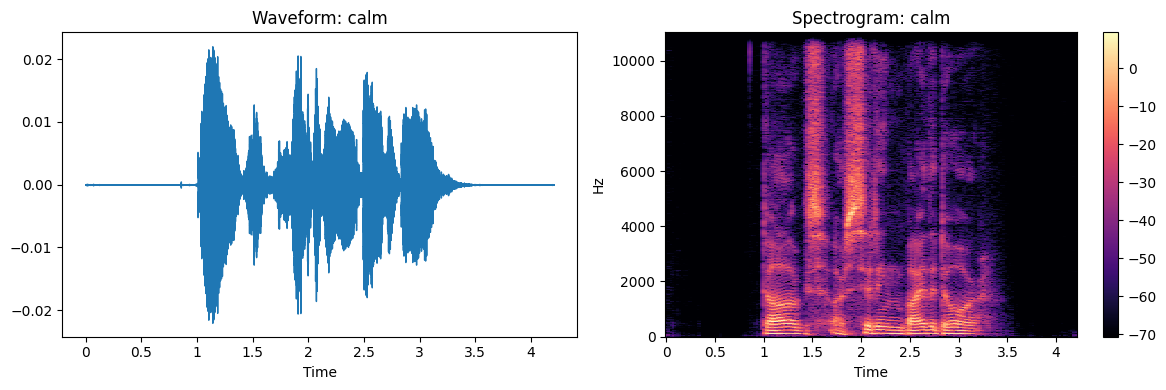

In [29]:
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd

def plot_and_play_audio(file_path, title):
    # 1. Load the audio
    data, sr = librosa.load(file_path)
    
    # 2. Create the Visuals
    plt.figure(figsize=(12, 4))
    
    # Plot Waveform
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(data, sr=sr)
    plt.title(f'Waveform: {title}')
    
    # Plot Spectrogram (shows frequency intensity)
    plt.subplot(1, 2, 2)
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()
    plt.title(f'Spectrogram: {title}')
    
    plt.tight_layout()
    plt.show()
    
    # 3. Add the Play Button
    return ipd.Audio(file_path)

# --- HOW TO TEST IT ---
# Pick a random row from your dataframe (e.g., row 10)
sample_row = data_df.iloc[10]
plot_and_play_audio(sample_row['path'], sample_row['emotion'])